In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math
import copy

In [2]:
image = cv2.imread('sar_3.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

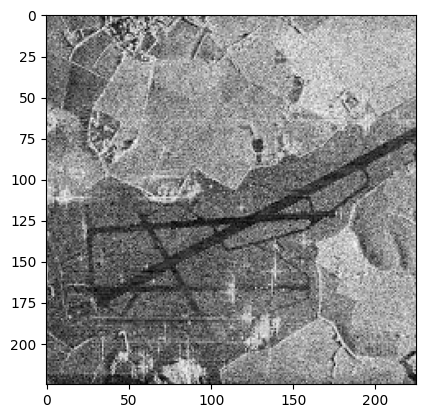

In [3]:
plt.imshow(image_gray, cmap="gray")

# 1. Для изображения sar_3.jpg найти наиболее протяженный участок

In [4]:
image_blur = cv2.medianBlur(image_gray, 5)

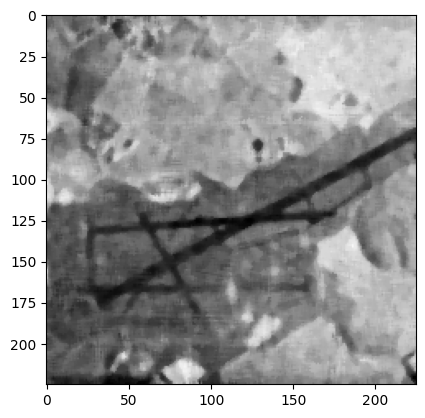

In [5]:
plt.imshow(image_blur, cmap="gray")

In [6]:
canny = cv2.Canny(image_blur,50,150,apertureSize = 3)
lines = cv2.HoughLinesP(canny, 1, np.pi/180,
                        threshold=100,
                        minLineLength=10,
                        maxLineGap=20)

In [7]:
max_line = None
max_len = 0

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line
        line_len = math.hypot(x2 - x1, y2 - y1)
        if line_len > max_len:
            max_len = line_len
            max_line = (x1, y1, x2, y2)



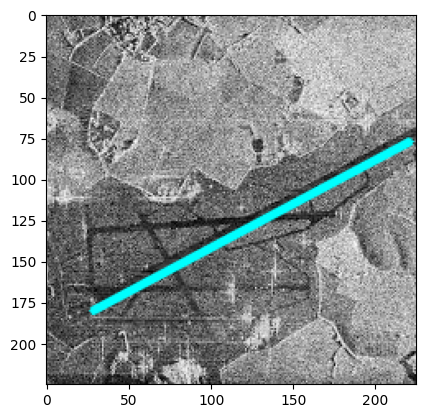

In [8]:
cv2.line(image, (x1, y1), (x2, y2), (0,255,255), 3, cv2.LINE_AA)
plt.imshow(image)

Выделенная линия наиболее протяженная

# 2. Для изображения sar_3.jpg провести исследование алгоритмов бинаризации, выделить участок дорожной полосы.

Точечная бинаризация

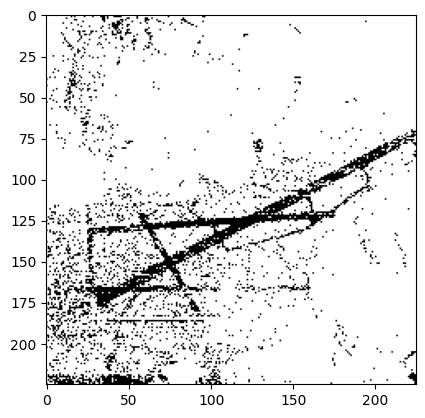

In [12]:
bin_img = copy.deepcopy(image_gray)
T  = 65
bin_img[image_gray < T] = 0
bin_img[image_gray >= T] = 255
plt.imshow(bin_img, cmap="gray")

Бинаризация Отсу

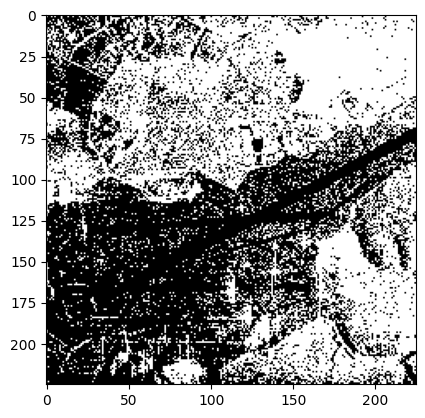

In [13]:
_,otsu = cv2.threshold(image_gray,0,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.imshow(otsu, cmap="gray")

Адаптивная бинаризация

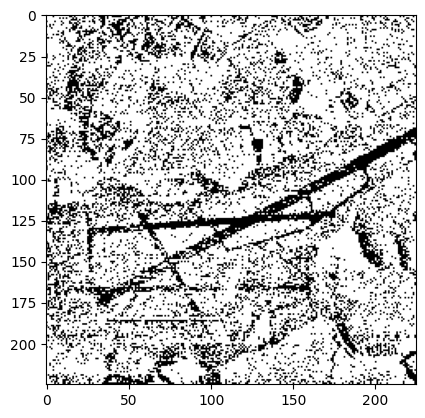

In [14]:
adapt = cv2.adaptiveThreshold(image_gray,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY,75,25)
plt.imshow(adapt, cmap="gray")